# Binary image classification of cats and dogs using a PyTorch Neural Network

In [ ]:
"""
# Project Title:
PyTorch Deep Neural Network (DNN) for cats / dogs image classification and Model Evaluation

# Core tech:
Key tools are:
•	Python | Google Colab
•	Deep Learning Framework (PyTorch)
•	Libraries: matplotlib | torch | torch.nn | torchvision | torch.optim
•	Data processing framework (torchvision.datasets.ImageFolder and torch.utils.data.DataLoader

# Project objective:
Main objectives are:
•	Import image datasets using torchvision transforms.
•	 Normalize datasets
•	Create a deep neural network (DNN) image classifier with PyTorch.
•	Sort images into 2 classes.
•	Analyze the model’s capability using training accuracy and loss.
•	Review the model’s training results using accuracy and loss measurements.

# Main ways:
•	Importing datasets
•	Normalizing datasets
•	Google drive used for loading dataset
•	Used data loader for batching
•	Verification for input data
•	Design deep neural network
•	Use optimizer
•	Find loss function
•	Training model and testing it

"""

In [ ]:
import torch

In [ ]:
import torchvision
from torchvision import transforms

# Image transformation pipeline for Deep Neural Network (DNN) training

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((64, 64)),   # Transform all input images into a 64 x 64 pixel format.
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


# Connect Google Drive to load the cat and dog image dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader

train_dataset = datasets.ImageFolder(root="/content/drive/MyDrive/deep_learning/NeuralNetwork/data/train", transform=transform)

train_data_loader  = DataLoader(train_dataset, batch_size=8, shuffle=True)

# Check: Are there dogs and cats in the dataset?

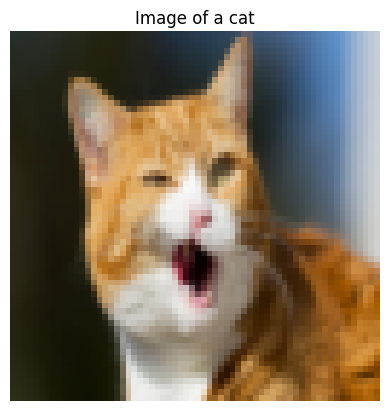

In [ ]:
import matplotlib.pyplot as plt

# Cat image from dataset

image_sample, label_sample = train_dataset[8]

plt.imshow(image_sample.permute(1,2,0)*0.5 + 0.5)

plt.title('Image of a cat')

plt.axis('off')

plt.show()

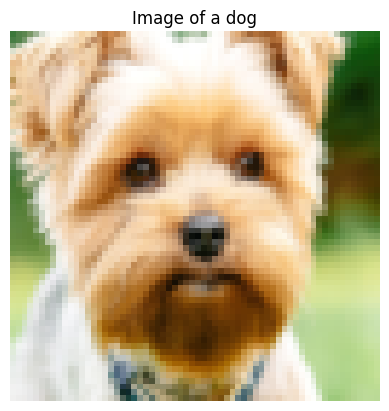

In [ ]:
# dog image from dataset

image_sample, label_sample = train_dataset[-12]

plt.imshow(image_sample.permute(1,2,0)*0.5 + 0.5)

plt.title('Image of a dog')

plt.axis('off')

plt.show()

# Simple neural network image classifier for cat vs dog classification

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class  Simple_Neural_Network_Image_Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        # Building the linear layers of the Neural Network structure
        self.hidden_layer = nn.Linear(64 * 64 * 3, 128)       # Input: flattened image (64 x 64 x 3), Output: 128 neurons
        self.output_layer = nn.Linear(128, 2)  #  Output layer: 2 neurons representing cat or dog.

    # Passing data through the layers
    def forward(self, x):
        x = x.view(x.size(0), -1) # Flatten the input image into a 1D vector.
        x = F.relu(self.hidden_layer(x))
        x = self.output_layer(x)
        return x

In [ ]:
# Set Up Loss Function and Optimizer

import torch.optim as optim

model =  Simple_Neural_Network_Image_Classifier()

loss_function = nn.CrossEntropyLoss()

training_optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training the model

In [ ]:
#  Training the Model and Save the model at each epoch

# Define the path for saving the model
cats_dogs_classifier_file_path = './cats_dogs_classifier.pth'

n_training_epochs = 6

for training_epoch in range(n_training_epochs):
  model.train()

  # Initializing Variables
  epoch_loss = 0.0
  correct_train_predictions = 0
  total_training_samples = 0

  for images, labels in train_data_loader:
    training_optimizer .zero_grad()    # Clear gradients from previous step
    model_predictions = model(images)
    training_loss = loss_function(model_predictions, labels)
    training_loss.backward()
    training_optimizer.step()

    epoch_loss += training_loss.item()
    _, train_outputs_predicted = torch.max(model_predictions.data, 1)
    total_training_samples += labels.size(0)
    correct_train_predictions += (train_outputs_predicted == labels).sum().item()

  train_classification_accuracy = 100 *  correct_train_predictions / total_training_samples

  print(f"training epoch {training_epoch+1}/{n_training_epochs }")
  print(f"Loss: {epoch_loss/len(train_data_loader):.4f}")
  print(f"Train Accuracy: {train_classification_accuracy:.2f}%")

  # Save the model
  torch.save(model.state_dict(), cats_dogs_classifier_file_path)
  print(f'Model properly saved at {cats_dogs_classifier_file_path}')


training epoch 1/6
Loss: 1.7597
Train Accuracy: 60.93%
Model properly saved at ./cats_dogs_classifier.pth
training epoch 2/6
Loss: 0.8211
Train Accuracy: 80.47%
Model properly saved at ./cats_dogs_classifier.pth
training epoch 3/6
Loss: 0.4570
Train Accuracy: 88.37%
Model properly saved at ./cats_dogs_classifier.pth
training epoch 4/6
Loss: 0.3325
Train Accuracy: 88.84%
Model properly saved at ./cats_dogs_classifier.pth
training epoch 5/6
Loss: 0.1512
Train Accuracy: 93.95%
Model properly saved at ./cats_dogs_classifier.pth
training epoch 6/6
Loss: 0.1220
Train Accuracy: 95.81%
Model properly saved at ./cats_dogs_classifier.pth
